# Homework 6 Punto 4.H: Valutazione Comparativa delle 6 Pipeline

Notebook dedicato alla **valutazione comparativa finale** richiesta dalla specifica dell'Homework:
> **Punto 4.H**: *Valutare le prestazioni di diverse pipeline (B1-dedupe, B2-dedupe, B1-RecordLinkage, B2-RecordLinkage, B1-ditto, B2-ditto) in termini di precision, recall, F1-measure, tempi di training, tempi di inferenza.*

### Struttura dell'esperimento
1. **B1**: Blocking esatto su `make`
2. **B2**: Blocking Sorted Neighbourhood su `year` ($w=1$)
3. **Tre paradigmi a confronto**:
   - **Record Linkage (Rule-based)**: matching deterministico ponderato con risoluzione conflitti 1-to-1
   - **Dedupe (Active / Supervised ML)**: regressione logistica probabilistica su distanze eterogenee con risoluzione 1-to-1
   - **Ditto (Deep Learning)**: Transformer `roberta-base` fine-tuned con serializzazione testuale e matching 1-to-1


## Configurazione Ambiente, Dipendenze e Logger


In [1]:
%pip install -q loguru tabulate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.7 MB/s eta 0:00:00


In [2]:
import os
import sys
import json
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

os.environ['TZ'] = 'Europe/Rome'
time.tzset()

logger.remove()
logger.add(
    sys.stdout,
    colorize=True,
    format="<green>{time:YYYY-MM-DD HH:mm:ss}</green> | <level>{level: <8}</level> | <cyan>{message}</cyan>"
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.dpi'] = 150

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = Path('/content/drive/MyDrive/data')
    if not DRIVE_DIR.exists() and Path('/content/drive/MyDrive/ing_dati/data').exists():
        DRIVE_DIR = Path('/content/drive/MyDrive/ing_dati/data')
except Exception:
    DRIVE_DIR = Path('.')

logger.info(f"Ambiente configurato con successo. Directory di riferimento: {DRIVE_DIR}")

Mounted at /content/drive
2026-09-14 17:00:34 | INFO     | Ambiente configurato con successo. Directory di riferimento: /content/drive/MyDrive/data


##Caricamento Automatico di TUTTI i Risultati Reali dai 3 Notebook Sorgente



In [3]:
#percorsi dei 3 artifact reali prodotti dai notebook sorgente (Punto 4.E/4.F/4.G)
RL_RESULTS_PATH = DRIVE_DIR / 'recordlinkage_results.csv'
DEDUPE_RESULTS_PATH = DRIVE_DIR / 'dedupe_results_final.csv'
DITTO_RESULTS_PATH = DRIVE_DIR / 'ditto_used_cars' / 'ditto_results.csv'

missing_sources = [
    str(p) for p in [RL_RESULTS_PATH, DEDUPE_RESULTS_PATH, DITTO_RESULTS_PATH] if not p.exists()
]
assert not missing_sources, (
    "Mancano questi artifact su Drive (rilancia il notebook sorgente corrispondente prima di procedere): "
    + ", ".join(missing_sources)
)

df_rl_raw = pd.read_csv(RL_RESULTS_PATH)
df_dedupe_raw = pd.read_csv(DEDUPE_RESULTS_PATH)
df_ditto_raw = pd.read_csv(DITTO_RESULTS_PATH)

logger.info(f"Caricato {RL_RESULTS_PATH.name}: {len(df_rl_raw)} righe")
logger.info(f"Caricato {DEDUPE_RESULTS_PATH.name}: {len(df_dedupe_raw)} righe")
logger.info(f"Caricato {DITTO_RESULTS_PATH.name}: {len(df_ditto_raw)} righe")

COMMON_COLUMNS = [
    'Pipeline', 'Paradigma', 'Blocking', 'Candidate Pairs',
    'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1',
    'Train Time (s)', 'Blocking Time (s)', 'Model Time (s)', 'Selection Time (s)', 'Matching Time (s)', 'Inference Time (s)'
]

df_rl = df_rl_raw[df_rl_raw['Set'] == 'Test'].copy()
df_dedupe = df_dedupe_raw[df_dedupe_raw['Set'] == 'Test'].copy()
df_ditto = df_ditto_raw[df_ditto_raw['Set'] == 'Test'].copy()

#Le 6 pipeline richieste dal 4.H: RecordLinkage-Regole, Dedupe (tutte le righe di Test), Ditto-1:1
df_rl['Richiesta 4.H'] = df_rl['Paradigma'] == 'Rule-Based'
df_dedupe['Richiesta 4.H'] = True
df_ditto['Richiesta 4.H'] = ~df_ditto['Pipeline'].str.contains(r'\(Raw', regex=True)

df_comparison = pd.concat([df_rl, df_dedupe, df_ditto], ignore_index=True)

#etichetta descrittiva per il blocking, solo a scopo di visualizzazione nel report (i valori sorgente restano Make/Year)
BLOCKING_DISPLAY = {'Make': 'Make (B1)', 'Year': 'Year (B2)'}
df_comparison['Blocking'] = df_comparison['Blocking'].map(BLOCKING_DISPLAY).fillna(df_comparison['Blocking'])

#controlli di coerenza: 6 pipeline richieste dal Punto 4.H + 4 varianti extra (RL-LR B1/B2, Ditto-Raw B1/B2)
assert len(df_comparison) == 10, f"Attese 10 righe (6 richieste + 4 extra), trovate {len(df_comparison)}: {df_comparison['Pipeline'].tolist()}"
assert df_comparison[COMMON_COLUMNS].isna().sum().sum() == 0, "Valori mancanti nella tabella consolidata"

n_required = df_comparison['Richiesta 4.H'].sum()
logger.success(f"Tabella master consolidata da artifact reali: {len(df_comparison)} righe totali "
               f"({n_required} appartenenti alle 6 pipeline richieste dal 4.H, {len(df_comparison) - n_required} varianti extra).")
display(df_comparison[COMMON_COLUMNS + ['Richiesta 4.H']])


2026-09-14 17:00:39 | INFO     | Caricato recordlinkage_results.csv: 4 righe
2026-09-14 17:00:39 | INFO     | Caricato dedupe_results_final.csv: 4 righe
2026-09-14 17:00:39 | INFO     | Caricato ditto_results.csv: 4 righe
2026-09-14 17:00:39 | SUCCESS  | Tabella master consolidata da artifact reali: 10 righe totali (6 appartenenti alle 6 pipeline richieste dal 4.H, 4 varianti extra).


,Pipeline,Paradigma,Blocking,Candidate Pairs,TP,FP,FN,Precision,Recall,F1,Train Time (s),Blocking Time (s),Model Time (s),Selection Time (s),Matching Time (s),Inference Time (s),Richiesta 4.H
0,B1 - RecordLinkage (Regole),Rule-Based,Make (B1),43456,687,22,103,0.968970,0.869620,0.916611,0.000000,0.009080,0.563365,0.014183,0.577548,0.586627,True
1,B2 - RecordLinkage (Regole),Rule-Based,Year (B2),49757,688,21,102,0.970381,0.870886,0.917945,0.000000,0.010906,0.507477,0.012061,0.519537,0.530443,True
2,B1 - RecordLinkage (Logistic Regression),Supervised ML (RecordLinkage),Make (B1),43456,746,499,44,0.599197,0.944304,0.733170,0.024710,0.009969,0.477167,0.001872,0.479039,0.489007,False
3,B2 - RecordLinkage (Logistic Regression),Supervised ML (RecordLinkage),Year (B2),49757,746,496,44,0.600644,0.944304,0.734252,0.024710,0.010773,0.507362,0.001937,0.509298,0.520072,False
4,B1 - Dedupe,Supervised ML (Dedupe),Make (B1),43456,666,111,124,0.857143,0.843038,0.850032,422.626563,0.009665,7.207804,0.024964,7.232768,7.242433,True
5,B2 - Dedupe,Supervised ML (Dedupe),Year (B2),49757,672,114,118,0.854962,0.850633,0.852792,422.626563,0.011595,7.252684,0.034058,7.286742,7.298337,True
6,B1 - Ditto (roberta) (Raw matcher.py),Deep Learning (Transformer),Make (B1),43456,665,74,125,0.899865,0.841772,0.869850,1209.555777,0.045198,1121.335139,0.000000,1121.335139,1121.380337,False
7,B1 - Ditto (roberta),Deep Learning (Transformer),Make (B1),43456,651,9,139,0.986364,0.824051,0.897931,1209.555777,0.045198,1121.335139,0.002435,1121.337574,1121.382772,True
8,B2 - Ditto (roberta) (Raw matcher.py),Deep Learning (Transformer),Year (B2),49757,672,78,118,0.896000,0.850633,0.872727,1209.555777,0.054133,1270.455887,0.000000,1270.455887,1270.510020,False
9,B2 - Ditto (roberta),Deep Learning (Transformer),Year (B2),49757,657,9,133,0.986486,0.831646,0.902473,1209.555777,0.054133,1270.455887,0.002041,1270.457928,1270.512062,True


##Tabella Master Comparativa (Punto 4.H)

Due tabelle separate:
1. **Tabella principale**: solo le 6 pipeline richieste esplicitamente dal Punto 4.H (B1/B2 su RecordLinkage-Regole, Dedupe, Ditto-1:1).
2. **Tabella extra**: le 4 varianti aggiuntive (RecordLinkage-Logistic Regression, Ditto-Raw) utili per la discussione critica ma non richieste dalla consegna.

Le celle con le performance migliori sono evidenziate automaticamente **all'interno di ciascuna tabella separatamente**.


In [4]:
display_cols = [
    'Pipeline', 'Paradigma', 'Blocking', 'Candidate Pairs',
    'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1',
    'Train Time (s)', 'Inference Time (s)'
]

fmt = {
    'Candidate Pairs': '{:,d}',
    'TP': '{:d}',
    'FP': '{:d}',
    'FN': '{:d}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
    'Train Time (s)': '{:.2f}',
    'Inference Time (s)': '{:.3f}'
}

#tabella principale: solo le 6 pipeline richieste dal Punto 4.H
df_required = df_comparison[df_comparison['Richiesta 4.H']].reset_index(drop=True)
logger.info(f"Tabella principale (Punto 4.H): {len(df_required)} pipeline richieste")

styled_table = (
    df_required[display_cols]
    .style
    .format(fmt)
    .highlight_max(subset=['Precision', 'Recall', 'F1'], color='#4da86c')
    .highlight_min(subset=['Train Time (s)', 'Inference Time (s)'], color='#800020')
)
display(styled_table)

#tabella secondaria: varianti extra (RecordLinkage-Logistic Regression, Ditto-Raw) a scopo di approfondimento critico
df_extra = df_comparison[~df_comparison['Richiesta 4.H']].reset_index(drop=True)
if not df_extra.empty:
    logger.info(f"Tabella extra (approfondimento, non richiesta dal 4.H): {len(df_extra)} varianti")
    styled_table_extra = (
        df_extra[display_cols]
        .style
        .format(fmt)
        .highlight_max(subset=['Precision', 'Recall', 'F1'], color='#4da86c')
        .highlight_min(subset=['Train Time (s)', 'Inference Time (s)'], color='#800020')
    )
    display(styled_table_extra)


2026-09-14 17:00:39 | INFO     | Tabella principale (Punto 4.H): 6 pipeline richieste


,Pipeline,Paradigma,Blocking,Candidate Pairs,TP,FP,FN,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,B1 - RecordLinkage (Regole),Rule-Based,Make (B1),"43,456",687,22,103,0.9690,0.8696,0.9166,0.00,0.587
1,B2 - RecordLinkage (Regole),Rule-Based,Year (B2),"49,757",688,21,102,0.9704,0.8709,0.9179,0.00,0.530
2,B1 - Dedupe,Supervised ML (Dedupe),Make (B1),"43,456",666,111,124,0.8571,0.8430,0.8500,422.63,7.242
3,B2 - Dedupe,Supervised ML (Dedupe),Year (B2),"49,757",672,114,118,0.8550,0.8506,0.8528,422.63,7.298
4,B1 - Ditto (roberta),Deep Learning (Transformer),Make (B1),"43,456",651,9,139,0.9864,0.8241,0.8979,1209.56,1121.383
5,B2 - Ditto (roberta),Deep Learning (Transformer),Year (B2),"49,757",657,9,133,0.9865,0.8316,0.9025,1209.56,1270.512


2026-09-14 17:00:39 | INFO     | Tabella extra (approfondimento, non richiesta dal 4.H): 4 varianti


,Pipeline,Paradigma,Blocking,Candidate Pairs,TP,FP,FN,Precision,Recall,F1,Train Time (s),Inference Time (s)
0,B1 - RecordLinkage (Logistic Regression),Supervised ML (RecordLinkage),Make (B1),"43,456",746,499,44,0.5992,0.9443,0.7332,0.02,0.489
1,B2 - RecordLinkage (Logistic Regression),Supervised ML (RecordLinkage),Year (B2),"49,757",746,496,44,0.6006,0.9443,0.7343,0.02,0.520
2,B1 - Ditto (roberta) (Raw matcher.py),Deep Learning (Transformer),Make (B1),"43,456",665,74,125,0.8999,0.8418,0.8698,1209.56,1121.380
3,B2 - Ditto (roberta) (Raw matcher.py),Deep Learning (Transformer),Year (B2),"49,757",672,78,118,0.8960,0.8506,0.8727,1209.56,1270.510


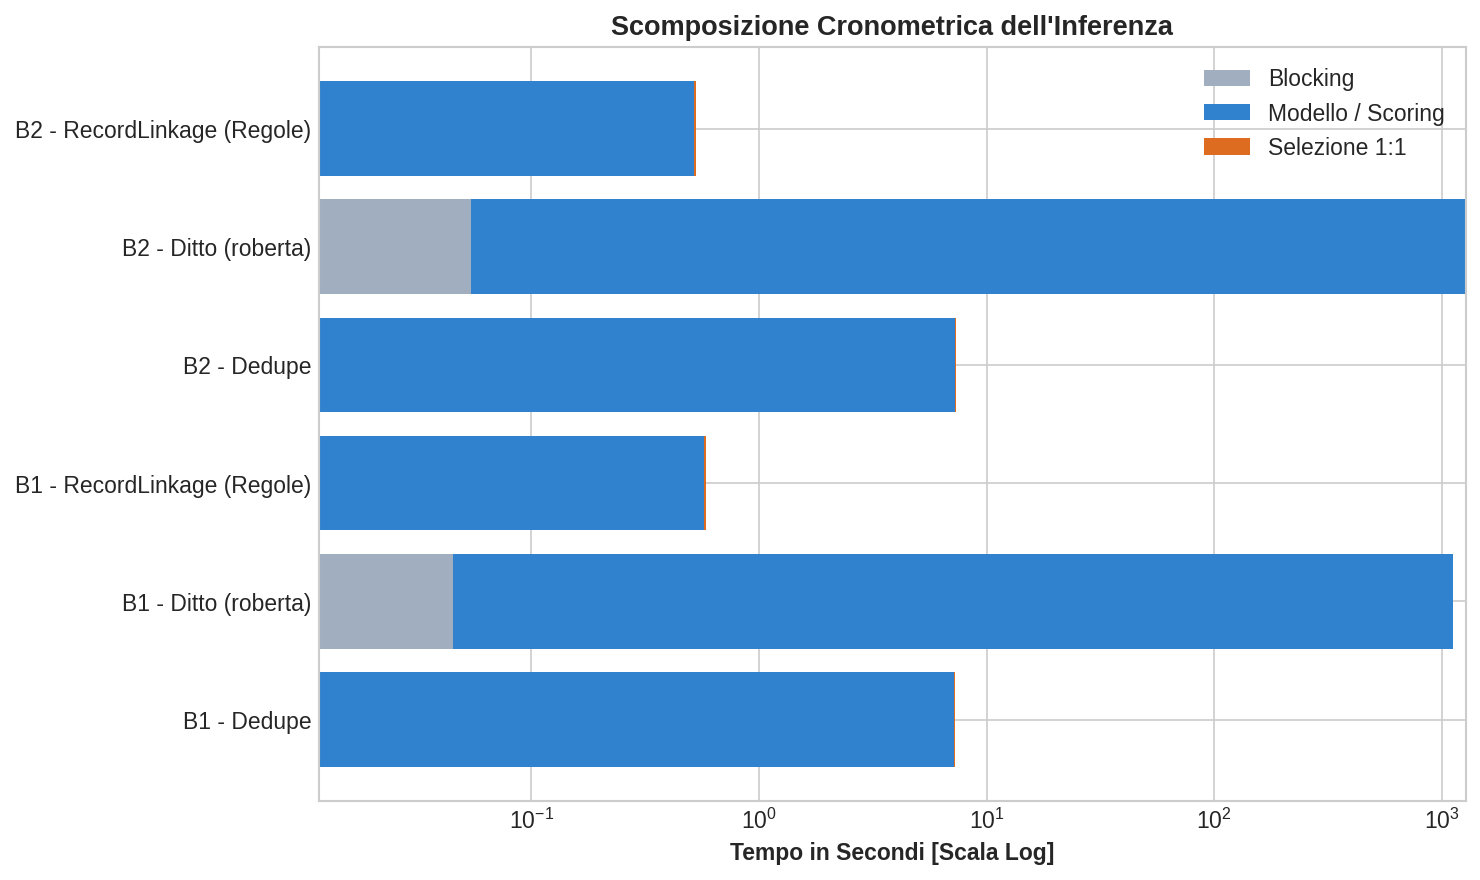

In [5]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = df_required.sort_values("Pipeline")

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(df_plot))

ax.barh(y, df_plot["Blocking Time (s)"], color="#a0aec0", label="Blocking")
ax.barh(y, df_plot["Model Time (s)"], left=df_plot["Blocking Time (s)"], color="#3182ce", label="Modello / Scoring")
ax.barh(y, df_plot["Selection Time (s)"],
        left=df_plot["Blocking Time (s)"] + df_plot["Model Time (s)"],
        color="#dd6b20", label="Selezione 1:1")

ax.set_yticks(y)
ax.set_yticklabels(df_plot["Pipeline"])
ax.set_xscale("log")
ax.set_xlabel("Tempo in Secondi [Scala Log]")
ax.set_title("Scomposizione Cronometrica dell'Inferenza")
ax.legend()
plt.tight_layout()
plt.savefig("timing_breakdown.png", dpi=150)
plt.show()

##Scomposizione Cronometrica Dettagliata dell'Inferenza

Per analizzare i colli di bottiglia e la scalabilità dei diversi paradigmi (Rule-based, Supervised ML, Deep Learning), scomponiamo l'inferenza end-to-end nelle sue componenti elementari:
$$T_{\text{matching}} = T_{\text{model}} + T_{\text{selection}}$$
$$T_{\text{inferenza}} = T_{\text{blocking}} + T_{\text{matching}}$$
dove:
- **$T_{\text{blocking}}$**: generazione delle candidate pair dai dati tabellari grezzi;
- **$T_{\text{model}}$**: calcolo delle feature di similarità sintattiche o forward pass del Transformer;
- **$T_{\text{selection}}$**: applicazione della soglia $th^*$ e risoluzione dei vincoli di unicità 1-a-1.


In [6]:
timing_cols = [
    'Pipeline', 'Candidate Pairs', 'Blocking Time (s)', 'Model Time (s)', 'Selection Time (s)', 'Matching Time (s)', 'Inference Time (s)'
]

timing_df = df_comparison[timing_cols].copy()
timing_df['Matching Speed (pairs/s)'] = (timing_df['Candidate Pairs'] / timing_df['Matching Time (s)']).round(1)
timing_df['% Blocking'] = ((timing_df['Blocking Time (s)'] / timing_df['Inference Time (s)']) * 100).round(2)
timing_df['% Model'] = ((timing_df['Model Time (s)'] / timing_df['Inference Time (s)']) * 100).round(2)
timing_df['% Selection'] = ((timing_df['Selection Time (s)'] / timing_df['Inference Time (s)']) * 100).round(2)

styled_timing = (
    timing_df.style.format({
        'Candidate Pairs': '{:,d}',
        'Blocking Time (s)': '{:.3f}',
        'Model Time (s)': '{:.3f}',
        'Selection Time (s)': '{:.4f}',
        'Matching Time (s)': '{:.3f}',
        'Inference Time (s)': '{:.3f}',
        'Matching Speed (pairs/s)': '{:,.1f}',
        '% Blocking': '{:.2f}%',
        '% Model': '{:.2f}%',
        '% Selection': '{:.2f}%'
    })
)

display(styled_timing)

,Pipeline,Candidate Pairs,Blocking Time (s),Model Time (s),Selection Time (s),Matching Time (s),Inference Time (s),Matching Speed (pairs/s),% Blocking,% Model,% Selection
0,B1 - RecordLinkage (Regole),"43,456",0.009,0.563,0.0142,0.578,0.587,"75,242.3",1.55%,96.03%,2.42%
1,B2 - RecordLinkage (Regole),"49,757",0.011,0.507,0.0121,0.520,0.530,"95,771.8",2.06%,95.67%,2.27%
2,B1 - RecordLinkage (Logistic Regression),"43,456",0.010,0.477,0.0019,0.479,0.489,"90,715.0",2.04%,97.58%,0.38%
3,B2 - RecordLinkage (Logistic Regression),"49,757",0.011,0.507,0.0019,0.509,0.520,"97,697.2",2.07%,97.56%,0.37%
4,B1 - Dedupe,"43,456",0.010,7.208,0.0250,7.233,7.242,"6,008.2",0.13%,99.52%,0.34%
5,B2 - Dedupe,"49,757",0.012,7.253,0.0341,7.287,7.298,"6,828.4",0.16%,99.37%,0.47%
6,B1 - Ditto (roberta) (Raw matcher.py),"43,456",0.045,1121.335,0.0000,1121.335,1121.380,38.8,0.00%,100.00%,0.00%
7,B1 - Ditto (roberta),"43,456",0.045,1121.335,0.0024,1121.338,1121.383,38.8,0.00%,100.00%,0.00%
8,B2 - Ditto (roberta) (Raw matcher.py),"49,757",0.054,1270.456,0.0000,1270.456,1270.510,39.2,0.00%,100.00%,0.00%
9,B2 - Ditto (roberta),"49,757",0.054,1270.456,0.0020,1270.458,1270.512,39.2,0.00%,100.00%,0.00%


##Analisi Grafica dei Trade-off

Visualizziamo:
1. **Confronto metriche ER**: Precision, Recall ed F1-Score per ciascuna pipeline.
2. **Trade-off Accuratezza vs Efficienza**: F1-Score in funzione del tempo di inferenza (in scala logaritmica).
3. **Costi computazionali**: Tempi di Training e Inferenza a confronto.


/tmp/ipykernel_3838/2045604516.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8.5)
/tmp/ipykernel_3838/2045604516.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=40, ha='right', fontsize=8.5)


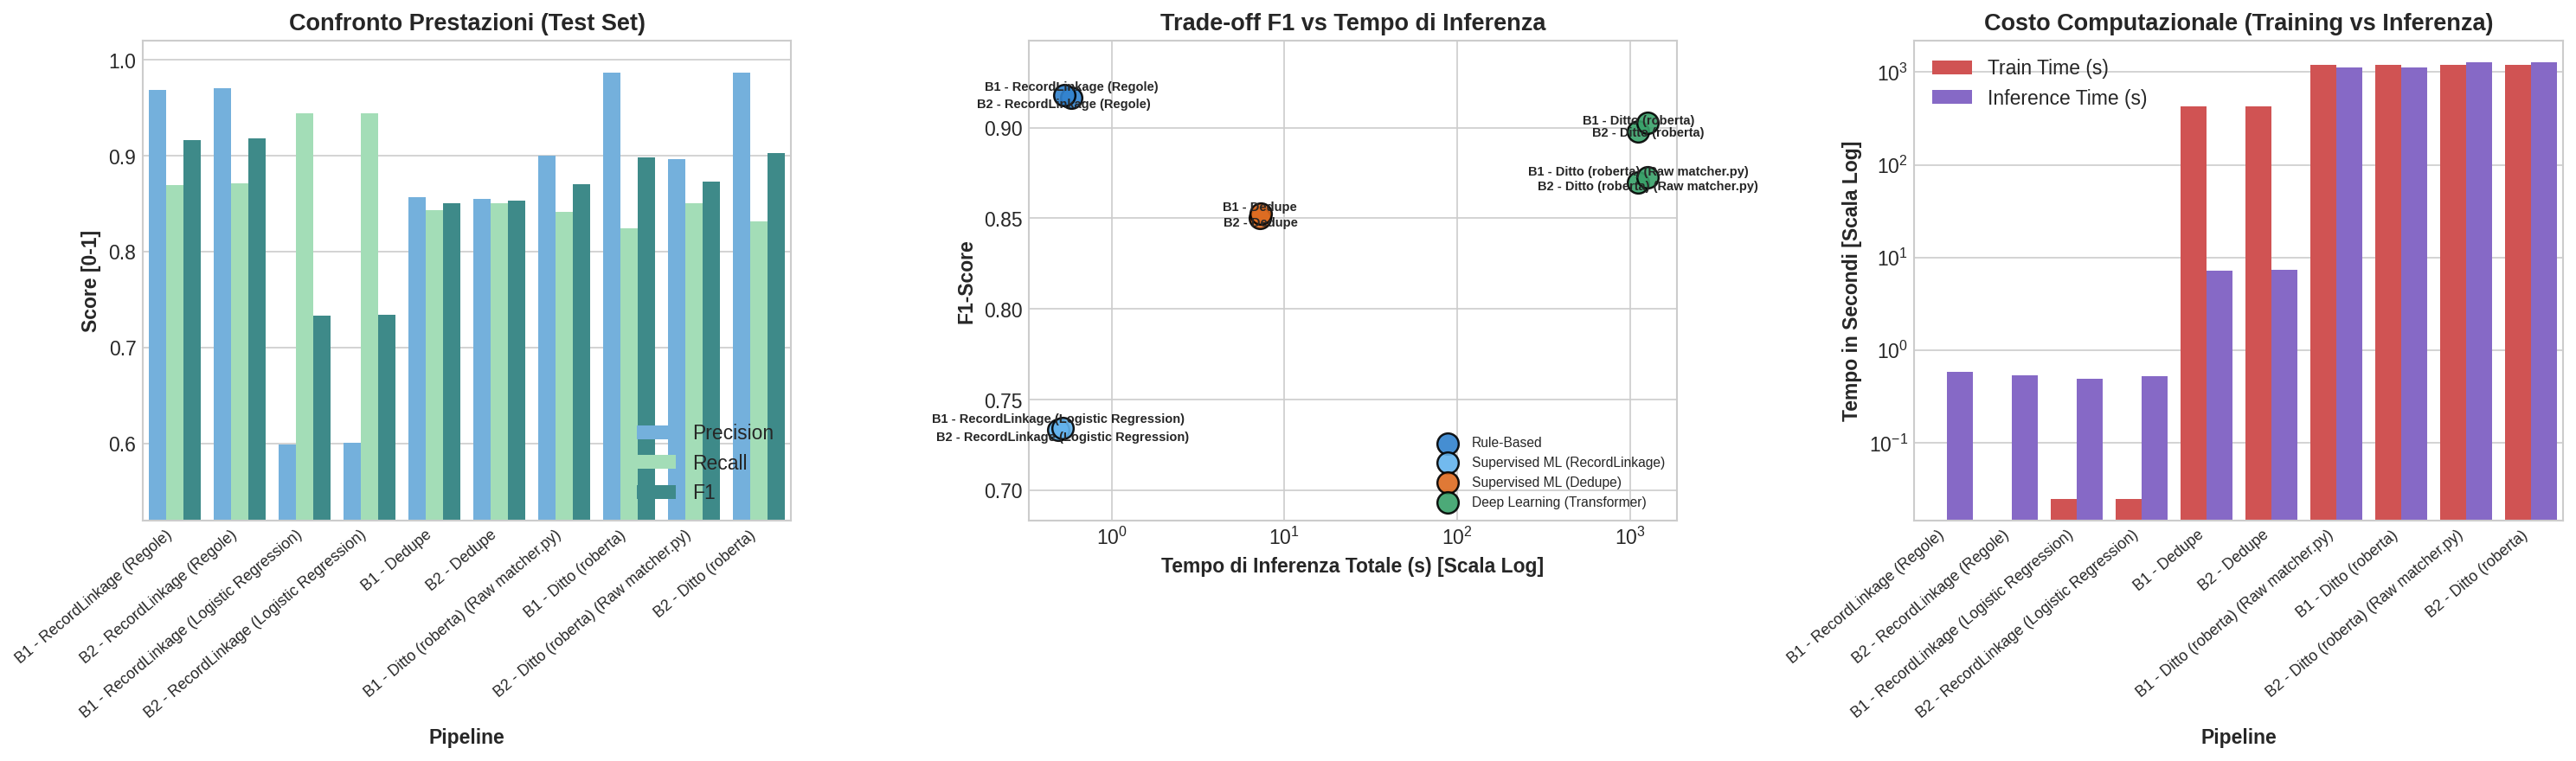

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

palette = {
    'Rule-Based': '#3182ce',
    'Supervised ML (RecordLinkage)': '#63b3ed',
    'Supervised ML (Dedupe)': '#dd6b20',
    'Deep Learning (Transformer)': '#38a169'
}

#Grafico a barre: F1, Precision, Recall
df_melted = df_comparison.melt(
    id_vars=['Pipeline', 'Paradigma'],
    value_vars=['Precision', 'Recall', 'F1'],
    var_name='Metrica',
    value_name='Valore'
)

sns.barplot(
    data=df_melted,
    x='Pipeline',
    y='Valore',
    hue='Metrica',
    ax=axes[0],
    palette=['#63b3ed', '#9ae6b4', '#319795']
)
axes[0].set_title('Confronto Prestazioni (Test Set)')
#limiti calcolati dinamicamente sui dati reali, invece di un range fisso pensato per 6 sole pipeline
score_min = df_melted['Valore'].min()
axes[0].set_ylim(max(0.0, score_min - 0.08), 1.02)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8.5)
axes[0].set_ylabel('Score [0-1]')
axes[0].legend(loc='lower right')

#Scatter: F1 vs Tempo Inferenza (log scale)
for paradigma, color in palette.items():
    sub = df_comparison[df_comparison['Paradigma'] == paradigma]
    if sub.empty:
        continue
    axes[1].scatter(
        sub['Inference Time (s)'],
        sub['F1'],
        label=paradigma,
        color=color,
        s=140,
        alpha=0.9,
        edgecolors='black',
        linewidth=1.2,
        zorder=3
    )

for _, row in df_comparison.iterrows():
    offset_y = 0.004 if 'B1' in row['Pipeline'] else -0.007
    axes[1].annotate(
        row['Pipeline'],
        (row['Inference Time (s)'], row['F1'] + offset_y),
        fontsize=7,
        fontweight='bold',
        ha='center'
    )

axes[1].set_xscale('log')
axes[1].set_title('Trade-off F1 vs Tempo di Inferenza')
axes[1].set_xlabel('Tempo di Inferenza Totale (s) [Scala Log]')
axes[1].set_ylabel('F1-Score')
#limiti dinamici: con Raw/LR incluse l'intervallo fisso 0.82-0.98 potrebbe tagliare punti fuori scala
f1_min, f1_max = df_comparison['F1'].min(), df_comparison['F1'].max()
axes[1].set_ylim(max(0.0, f1_min - 0.05), min(1.0, f1_max + 0.03))
axes[1].legend(loc='lower right', fontsize=7.5)

#Barplot: Tempi di Training vs Inferenza
time_melted = df_comparison.melt(
    id_vars=['Pipeline', 'Paradigma'],
    value_vars=['Train Time (s)', 'Inference Time (s)'],
    var_name='Fase',
    value_name='Secondi'
)

sns.barplot(
    data=time_melted,
    x='Pipeline',
    y='Secondi',
    hue='Fase',
    ax=axes[2],
    palette=['#e53e3e', '#805ad5']
)
axes[2].set_yscale('log')
axes[2].set_title('Costo Computazionale (Training vs Inferenza)')
axes[2].set_ylabel('Tempo in Secondi [Scala Log]')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=40, ha='right', fontsize=8.5)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()

##Esportazione Dati per la Relazione (CSV, Markdown e LaTeX)

I risultati finali vengono esportati automaticamente in tre formati per essere inseriti direttamente nel report di progetto.


In [8]:
output_csv = DRIVE_DIR / 'summary_6_pipelines_final.csv'
df_comparison.to_csv(output_csv, index=False)
logger.success(f"CSV salvato in: {output_csv}")

markdown_table = df_comparison[display_cols].to_markdown(index=False)
output_md = DRIVE_DIR / 'tabella_relazione.md'
with open(output_md, 'w', encoding='utf-8') as f:
    f.write(markdown_table)
logger.success(f"Tabella Markdown salvata in: {output_md}")

latex_table = df_comparison[display_cols].to_latex(
    index=False,
    float_format='%.4f',
    caption='Confronto delle prestazioni e dei costi computazionali delle 6 pipeline di Record Linkage sul Test Set (Punto 4.H).',
    label='tab:confronto_6_pipelines'
)
output_tex = DRIVE_DIR / 'tabella_relazione.tex'
with open(output_tex, 'w', encoding='utf-8') as f:
    f.write(latex_table)
logger.success(f"Tabella LaTeX per Overleaf salvata in: {output_tex}")
# Esportazione della tabella di scomposizione temporale disaggregata
timing_md = timing_df.to_markdown(index=False)
output_timing_md = DRIVE_DIR / 'tabella_tempi_disaggregati.md'
with open(output_timing_md, 'w', encoding='utf-8') as f:
    f.write(timing_md)
logger.success(f"Tabella Tempi Markdown salvata in: {output_timing_md}")

timing_tex = timing_df.to_latex(
    index=False,
    float_format='%.4f',
    caption='Scomposizione dettagliata dei tempi di inferenza per le pipeline di Record Linkage sul Test Set (Blocking, Modello, Selezione 1:1).',
    label='tab:tempi_disaggregati'
)
output_timing_tex = DRIVE_DIR / 'tabella_tempi_disaggregati.tex'
with open(output_timing_tex, 'w', encoding='utf-8') as f:
    f.write(timing_tex)
logger.success(f"Tabella Tempi LaTeX salvata in: {output_timing_tex}")


2026-09-14 17:00:42 | SUCCESS  | CSV salvato in: /content/drive/MyDrive/data/summary_6_pipelines_final.csv
2026-09-14 17:00:43 | SUCCESS  | Tabella Markdown salvata in: /content/drive/MyDrive/data/tabella_relazione.md
2026-09-14 17:00:44 | SUCCESS  | Tabella LaTeX per Overleaf salvata in: /content/drive/MyDrive/data/tabella_relazione.tex
2026-09-14 17:00:45 | SUCCESS  | Tabella Tempi Markdown salvata in: /content/drive/MyDrive/data/tabella_tempi_disaggregati.md
2026-09-14 17:00:46 | SUCCESS  | Tabella Tempi LaTeX salvata in: /content/drive/MyDrive/data/tabella_tempi_disaggregati.tex
